# 02 · Identifying One System From Scratch

Chapter 01 built the simulator and set the rules: the learner chooses an input, reads a noisy
position sensor, and fits a model that is missing two of the true system's effects. This chapter
asks the most direct question first: **treating every system on its own, with no help from any
other system, how well can we identify it?**

This "from-scratch" baseline is what every later chapter, which *does* use other systems, has to
beat.

---
## 1. Output-error identification

Given one experiment $(u_{0:T-1}, y_{0:T})$, **output-error identification** chooses the
coefficients whose simulated position best matches the measurements:

$$
\hat\eta = \arg\min_{\eta}\ \sum_{t=0}^{T} \big(y_t - \hat q_t(\eta; u)\big)^2 .
$$

We simulate the model *freely* from the known initial state rather than fitting one-step-ahead
differences. This avoids differentiating the noisy position to recover velocity: an equation-error
(regression) formulation would need the velocity and acceleration, i.e. first and second differences
of $y$, whose noise variances scale as $\sigma_y^2/\Delta t^2$ and $\sigma_y^2/\Delta t^4$. Output
error is the maximum-likelihood estimator under white measurement noise and a correct model; it is
not maximum likelihood in the presence of process noise, for which a state estimator such as an
extended Kalman filter would be appropriate. We keep the simpler estimator for transparency, and its
bias is part of what the experiments below measure.

The optimisation is started from a generic guess with physically sensible bounds, deliberately
**not** taken from the family structure of chapter 01, so from-scratch identification uses no
information about it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

import dynutils
from dynutils import sample_system, simulate, multisine, actuator, DT, X0

dynutils.set_style()
rng = np.random.default_rng(dynutils.SEED)
COLOR, NAMES = dynutils.COLOR, dynutils.NAMES

In [2]:
LOW = np.array([0.05, 0.01, 0.05, 0.0])
HIGH = np.array([5.0, 2.0, 3.0, 5.0])
GENERIC_GUESS = np.array([1.0, 0.5, 1.0, 0.5])


def predict(eta, u):
    # Learner's model: simulate positions. Vectorised: eta (..., 4) and u (..., T) broadcast.
    eta, u = np.asarray(eta, float), np.asarray(u, float)
    shape = np.broadcast_shapes(eta.shape[:-1], u.shape[:-1])
    k, d, b, a = (np.broadcast_to(eta[..., i], shape) for i in range(4))
    force = actuator(np.concatenate([np.zeros(u.shape[:-1] + (1,)), u[..., :-1]], axis=-1))
    q, v = np.full(shape, X0[0]), np.full(shape, X0[1])
    out = np.empty(shape + (u.shape[-1] + 1,)); out[..., 0] = q
    for t in range(u.shape[-1]):
        v = v + DT * (-k * q - d * v + b * force[..., t] - a * q**3)
        q = q + DT * v
        out[..., t + 1] = q
    return out


def fit_from_scratch(y, u, return_cov=False):
    residual = lambda eta: predict(eta, u) - y
    sol = least_squares(residual, GENERIC_GUESS, bounds=(LOW, HIGH), x_scale="jac")
    if not return_cov:
        return sol.x
    # Gauss-Newton covariance of the estimate: sigma^2 (J^T J)^-1
    return sol.x, np.mean(sol.fun**2) * np.linalg.pinv(sol.jac.T @ sol.jac)


def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

---
## 2. Short experiments versus long ones

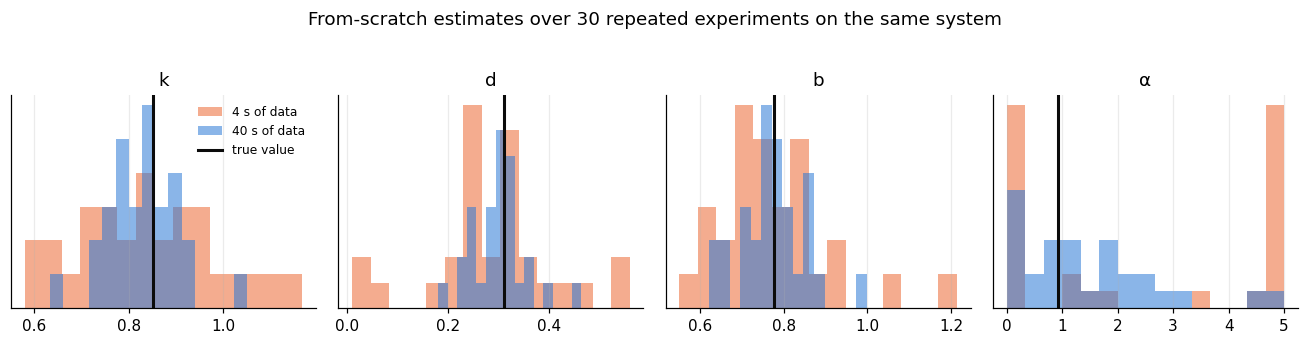

   4 s  median relative error: k= 11.1%  d= 22.1%  b=  8.6%  α=103.4%
  40 s  median relative error: k=  6.2%  d=  8.7%  b=  6.1%  α=100.0%


In [3]:
test = sample_system(rng)
estimates = {}
for T in (40, 400):                                      # 4 s versus 40 s of data
    estimates[T] = np.array([fit_from_scratch(simulate(test, u, rng)[1], u)
                             for u in (multisine(T, rng) for _ in range(30))])

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for j, ax in enumerate(axes):
    for T, col in ((40, COLOR["scratch"]), (400, COLOR["context"])):
        ax.hist(estimates[T][:, j], bins=15, alpha=0.55, color=col, label=f"{T*DT:.0f} s of data")
    ax.axvline(test["eta"][j], color=COLOR["truth"], lw=2, label="true value")
    ax.set(title=NAMES[j], yticks=[])
axes[0].legend(fontsize=8)
fig.suptitle("From-scratch estimates over 30 repeated experiments on the same system", y=1.03)
plt.tight_layout(); plt.show()

for T in (40, 400):
    rel = np.median(np.abs(estimates[T] - test["eta"]) / test["eta"], axis=0)
    print(f"{T*DT:>4.0f} s  median relative error:", "  ".join(f"{n}={100*r:5.1f}%" for n, r in zip(NAMES, rel)))

Two lessons carry through the rest of the course:

1. **Short experiments leave the coefficients poorly determined.** Four seconds is shorter than one
   oscillation period, so many coefficient combinations explain the data equally well. The estimates
   scatter widely.
2. **Some coefficients are hard to identify even with plenty of data.** The hardening term $\alpha$
   only matters at large deflections, and it competes with the unmodelled quintic term and the
   disturbance. With 40 s, $k$, $d$ and $b$ are within a few percent, but $\alpha$ is still uncertain
   by tens of percent. Identifiability depends on the *experiment* as much as on its length.

A new system gives us little data. The obvious question, and the subject of the rest of this
course: can other systems help?

---
## Exercises

### Exercise 1: How much does the guess matter?
Refit the 4-second experiments from three different starting guesses: the generic one used above,
one close to the true system, and one at the opposite corner of the bounds. Does the scatter of the
resulting estimates change?

<details><summary>Solution</summary>

```python
def fit_from(y, u, guess):
    residual = lambda eta: predict(eta, u) - y
    return least_squares(residual, guess, bounds=(LOW, HIGH), x_scale="jac").x

u4 = multisine(40, rng); _, y4 = simulate(test, u4, rng)
guesses = {"generic": GENERIC_GUESS, "near truth": test["eta"] * 1.05, "far corner": HIGH * 0.9}
{name: fit_from(y4, u4, g) for name, g in guesses.items()}
```
With so little data the cost surface is genuinely flat along several directions, so different
starting points can converge to different, equally-fitting solutions — the scatter in the figure
above is a property of the *data*, not an artefact of one starting guess.
</details>

### Exercise 2: A cleaner sensor
Repeat the 4-second study with the sensor noise cut to a tenth ($\sigma_y=0.001$) by scaling the
measurement noise term manually (`simulate` doesn't expose it, so add `0.1 * rng.normal(size=q.size)`
to a noise-free run instead of the built-in noisy one). Does better identifiability of $\alpha$
follow?

<details><summary>Solution</summary>

```python
def simulate_low_noise(system, u, rng):
    q, _ = simulate(system, u, rng, noise=False)
    return q, q + 0.001 * rng.normal(size=q.size)

low_noise = np.array([fit_from_scratch(simulate_low_noise(test, u, rng)[1], u)
                      for u in (multisine(40, rng) for _ in range(30))])
np.median(np.abs(low_noise - test["eta"]) / test["eta"], axis=0)
```
$\alpha$ improves a little but stays the worst-identified coefficient by far: its uncertainty is
dominated by *how little the hardening term is excited* at these amplitudes, not by sensor noise,
which is why quieter data alone does not fix it.
</details>